# **Εργασία 3**

**Καθηγητής:**  Θεοδωρακόπουλος Ηλίας

**Φοιτητής:** Ιατρού Κωνσταντίνος 58071

# **Άσκηση 2**
# **Ερώτημα B**

Επιλέξτε έναν αλγόριθμο ιεραρχικής ομαδοποίησης της αρεσκείας σας (agglomerative ή divisive) και εφαρμόστε τον στο ίδιο σύνολο δεδομένων με τα προηγούμενα. Να απαντηθούν τα παρακάτω:
Α. Περιγράψτε συνοπτικά την τεχνική που επιλέξατε και τις παραμέτρους που
χρησιμοποιήσατε (π.χ. μετρική, linkage method κλπ.). σε μία παράγραφο.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

Σε πρώτη φάση, όπως πάντα, εισάγω τις βιβλιοθήκες που θα χρειαστούν στην συνέχεια της άσκησης.



1.  Η numpy που χρησιμοποιήθηκε και στις προηγούμενες εργασίες, καθώς διευκολύνει πράξεις με πίνακες και διανύσματα λόγω της δομής ndarray που ορίζεται μέσω αυτής.
2.  Το module pyplot της matplotlib το οποίο χρησιμοποιείται για την τύπωση διαγραμμάτων.
3.  Η συνάρτηση linkage η οποία παίρνει στην είσοδο τα δεδομένα και επιστρέφει έναν πίνακα σύνδεσης για την παρουσίαση των clusters. (Δεν αποτελεί υλοποίηση της ιεραρχικής ομαδοποίησης, αλλά χρησιμοποιείται για την απεικόνιση της)
4.  Η συνάρτηση dendrogram που χρησιμοποιείται για την απεικόνιση δενδροδιαγράμματος.
5.  Η κλάση KMeans η οποία σε συνδιασμό με συναρτήσεις που ορίζονται για αντικείμενα της υλοποιεί τον αλγόριθμο clustering K-Means.
6.  Η συνάρτηση adjusted_rand_score που υπολογίζει την ομοιότητα μεταξύ δύο clusterings.
7. H κλάση AgglomerativeClustering η οποίά σε συνδιασμό με συναρτήσεις που ορίζονται στα πλαίσια της υλοποιεί την Ιεραρχική Ομαδοποίηση με bottom-up τεχνική.


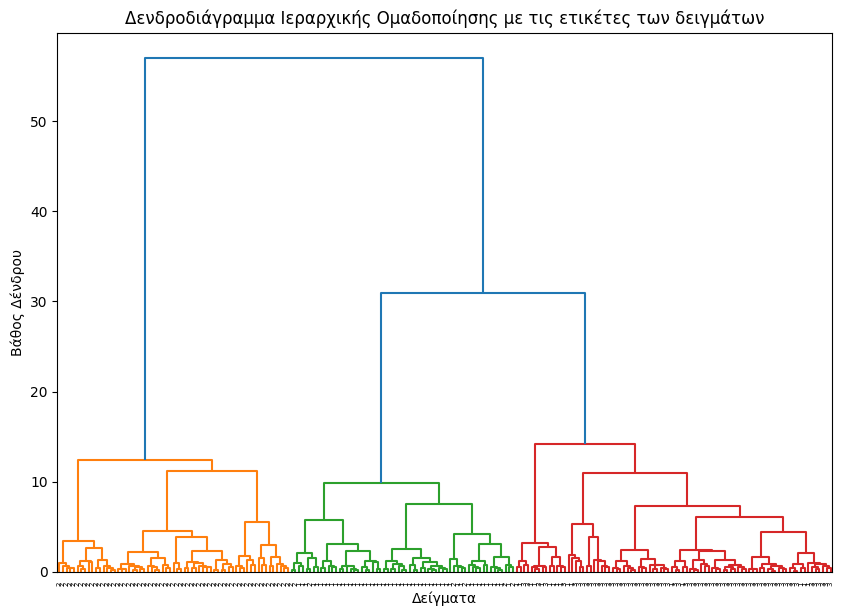

In [ ]:
# Εισαγωγή δεδομένων
data = np.loadtxt('seeds_dataset.txt', encoding=None)

# Διαχωρισμός δεδομένων από ετικέτες
features = data[:, :-1]
labels = data[:, -1].astype(int)

# Εφαρμογή Agglomerative Hierarchical Clustering με χρήση μεθόδου σύνδεσης Ward
linked = linkage(features, method='ward')

# Δημιουργία δενδροδιαγράμματος για την οπτικοποίηση ιεραρχικού clustering
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', color_threshold=20, labels=labels)
plt.title('Δενδροδιάγραμμα Ιεραρχικής Ομαδοποίησης με τις ετικέτες των δειγμάτων')
plt.xlabel('Δείγματα')
plt.ylabel('Βάθος Δένδρου')
plt.show()

Αρχικά εισάγουμε το σετ δεδομένων της προηγούμενης άσκησης (seeds_dataset.txt) και χωρίζουμε τα δεδομένα από τις ετικέτες τους (μεταβλητές features και labels).

Στην συνέχεια ορίζουμε την μεταβλητή linked που περιέχει έναν πίνακα με το δενδροδιάγραμμα της ιεραρχικής ομαδοποίησης και το τυπώνουμε.

Η το δενδροδιάγραμμα που δημιουργήθηκε ακολούθησε την τεχνική σύνδεσης ward, η οποία σαν μετρική χρησιμοποιεί μόνο την Ευκλείδεια.

Στις εντολές της τύπωσεις δηλώνουμε ως color_thrshold την τιμή 20 η οποία παίζει ρόλο απλά για τον χρωματισμό και η τιμή αυτή επιλέχθηκε ώστε να έχω τέτοιο χρωματισμό ώστε να φαίνεται ο διαχωρισμός σε 3 clusters. Η παράμετρος orientation='top' ορίζει ότι η ρίζα θα είναι στο πάνω μέρος του δενδροδιαγράμματος, ενώ η παράμετρος labels=labels ορίζει ότι θα φαίνονται οι ετικέτες των κλάσεων του κάθε δείγματος για κάθε δείγμα ξεχωριστά.

# Ερώτημα Γ
Χρησιμοποιήστε την ιεραρχική ομαδοποίηση που δημιουργήσατε ώστε να διαχωρίσετε τα δεδομένα σε 3 ομάδες. Χρησιμοποιήστε κάποιο κριτήριο εξωτερικής επικύρωσης (π.χ. rand index, adjusted rand index, mutual information κλπ) και συγκρίνετε την ομαδοποίηση αυτή με την αντίστοιχη που επιτυγχάνει ο k-means σε σχέση με τις ετικέτες των δεδομένων. Ποια μετρική επιτυγχάνει ομαδοποίηση πιο πιστή στις πραγματικές ομάδες των δεδομένων;


In [ ]:
# Εφαρμογή ιεραρχικής ομαδοποίησης με 3 ομάδες με διαφορετικές παραμέτρους
aggl_model_ward = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(features)
aggl_labels_ward = aggl_model_ward.fit_predict(features)

aggl_model_euclidean = AgglomerativeClustering(n_clusters=3, linkage='average', metric='euclidean').fit(features)
aggl_labels_euclidean = aggl_model_euclidean.fit_predict(features)

aggl_model_cosine = AgglomerativeClustering(n_clusters=3, linkage='average', metric='cosine').fit(features)
aggl_labels_cosine = aggl_model_cosine.fit_predict(features)

# Εφαρμογή k-means ομαδοποίησης με 3 ομάδες
kmeans_model = KMeans(n_clusters=3, n_init=1, random_state=123).fit(features)
kmeans_labels = kmeans_model.fit_predict(features)

# Επεξεργασία δεδομένων για να τα χρησιμοποιήσουμε στο μοντέλο k-means με μετρική cosine
length = (np.sqrt(features**2).sum(axis=1))[:, None]
features_cosine = features/length

kmeans_model_cosine = KMeans(n_clusters=3, n_init=1, random_state=123).fit(features_cosine)
kmeans_labels_cosine = kmeans_model.fit_predict(features_cosine)

# Υπολογισμός του Adjusted Rand Index για κάθε ένα από τα μοντέλα ομαδοποίησης
ri_ward = adjusted_rand_score(labels, aggl_labels_ward)
ri_euclidean = adjusted_rand_score(labels, aggl_labels_euclidean)
ri_cosine = adjusted_rand_score(labels, aggl_labels_cosine)
ri_kmeans = adjusted_rand_score(labels, kmeans_labels)
ri_kmeans_cosine = adjusted_rand_score(labels, kmeans_labels_cosine)


print("Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης ward, το Rand Index είναι", round(ri_ward, 4))
print("Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και ευκλείδεια μετρική, το Rand Index είναι", round(ri_euclidean, 4))
print("Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και cosine μετρικη, το Rand Index είναι", round(ri_cosine, 4))
print("Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για Ευκλείδεια μετρική, το Rand Index είναι", round(ri_kmeans, 4))
print("Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για cosine μετρική, το Rand Index είναι", round(ri_kmeans_cosine, 4))

Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης ward, το Rand Index είναι 0.7132
Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και ευκλείδεια μετρική, το Rand Index είναι 0.7442
Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και cosine μετρικη, το Rand Index είναι 0.3884
Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για Ευκλείδεια μετρική, το Rand Index είναι 0.7166
Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για cosine μετρική, το Rand Index είναι 0.3562


Αρχικά ορίζουμε τρία μοντέλα για ιεραχική ομαδοποίηση με agglomerative τεχνική και τα εκπαιδεύουμε πάνω στα δεδομένα. Το πρώτο μοντέλο ακολουθεί τεχνική σύνδεσης ward, ενώ τα άλλα δύο average. Η διαφοροποίηση μεταξύ του 2ου και του 3ου μοντέλου ομαδοποίησης είναι η μετρική που χρησιμοποιούν (ευκλείδεια και cosine). Αμέσως μετά δοκιμάζουμε τα μοντέλα για να συγκρίνουμε τα αποτελέσματα με τις πραγματικές ετικέτες.

Στη συνέχεια κάνουμε το ίδιο και για ένα μοντέλο k-means ομαδοποίησης.
Ακόμη επειδή το k-means μοντέλο δέχεται μόνο Ευκλειδεια μετρική επεξεργαστηκα τα δεδομένα έτσι ώστε να υλοποιήσουμε και ένα k-means μοντέλος για cosine μετρική.

Τέλος δίνουμε τα αποτελέσματα του κάθε μοντέλο για σύγκριση με τις πραγματικές ετικέτες ώστε να υπολογιστεί το Rand Index κάθε μοντέλου ομαδοποίησης και τυπώνουμε τα αποτελέσματα.

# Περαιτέρω δουλειά

Τα αποτελέσματα αν είχε γίνει κανονικοποίηση στα δεδομένα πριν γίνει η εκπαίδευση των μοντέλων.

In [ ]:
from sklearn.preprocessing import normalize
features_normalized = (features - np.mean(features, axis=0))/np.std(features, axis=0)

length = (np.sqrt(features_normalized**2).sum(axis=1))[:, None]
features_cosine = features_normalized/length

# Εφαρμογή ιεραρχικής ομαδοποίησης με 3 ομάδες με διαφορετικές παραμέτρους
aggl_model = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(features_normalized)
aggl_labels_ward = aggl_model.fit_predict(features_normalized)

aggl_model_euclidean = AgglomerativeClustering(n_clusters=3, linkage='average', metric='euclidean').fit(features_normalized)
aggl_labels_euclidean = aggl_model_euclidean.fit_predict(features_normalized)

aggl_model_cosine = AgglomerativeClustering(n_clusters=3, linkage='average', metric='cosine').fit(features_normalized)
aggl_labels_cosine = aggl_model_cosine.fit_predict(features_normalized)

# Εφαρμογή k-means ομαδοποίησης με 3 ομάδες
kmeans_model = KMeans(n_clusters=3, n_init=1, random_state=123).fit(features_normalized)
kmeans_labels = kmeans_model.fit_predict(features_normalized)

kmeans_model_cosine = KMeans(n_clusters=3, n_init=1, random_state=123).fit(features_cosine)
kmeans_labels_cosine = kmeans_model_cosine.fit_predict(features_cosine)

# Υπολογισμός του Adjusted Rand Index για κάθε ένα από τα μοντέλα ομαδοποίησης
ri_ward = adjusted_rand_score(labels, aggl_labels_ward)
ri_euclidean = adjusted_rand_score(labels, aggl_labels_euclidean)
ri_cosine = adjusted_rand_score(labels, aggl_labels_cosine)
ri_kmeans = adjusted_rand_score(labels, kmeans_labels)
ri_kmeans_cos = adjusted_rand_score(labels, kmeans_labels_cosine)


print("Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης ward, το Rand Index είναι", round(ri_ward, 4))
print("Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και ευκλείδεια μετρική, το Rand Index είναι", round(ri_euclidean, 4))
print("Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και cosine μετρικη, το Rand Index είναι", round(ri_cosine, 4))
print("Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για Ευκλείδεια μετρική, το Rand Index είναι", round(ri_kmeans, 4))
print("Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για cosine μετρική, το Rand Index είναι", round(ri_kmeans_cos, 4))

Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης ward, το Rand Index είναι 0.797
Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και ευκλείδεια μετρική, το Rand Index είναι 0.6859
Στην περίπτωση του ιεραρχικού μοντέλου ομαδοποίησης με τεχνική συγχώνευσης average και cosine μετρικη, το Rand Index είναι 0.7889
Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για Ευκλείδεια μετρική, το Rand Index είναι 0.7733
Στην περίπτωση του K-Means μοντέλου ομαδοποίησης για cosine μετρική, το Rand Index είναι 0.689


Η διαδιασία για να πάρουμε τις τιμές είναι ακριβώς ίδια με αυτή του Γ ερωτήματος απλά εργαστήκαμε πάνω στα κανονικοποιημένα δεδομένα αντί να εργαστούμε πάνω στα αρχικά.